# Cernere - Reconhecimento de Dígitos Manuscritos

*Problema preditivo:* Classificação de dígitos manuscritos (0-9) a partir de imagens.

O presente projeto tem como objetivo treinar e avaliar modelos de aprendizado de máquina e redes neurais para reconhecer dígitos manuscritos a partir de imagens, utilizando o conjunto de dados MNIST. O projeto inclui etapas de pré-processamento, treinamento de modelos, avaliação de desempenho, experimentos com classes ocultadas e inferência com imagens manuscritas próprias.

*Dataset:* MNIST (Modified National Institute of Standards and Technology database), obtido da biblioteca `sklearn.datasets`. Trata-s de um conjunto de $70.000$ imagens em escala de cinza de dígitos manuscritos, com dimensões de $28 \times 28$ pixels, aplanadas em vetores contínuos de $784$ colunas/features e devidamente rotuladas com os dígitos correspondentes (0-9).

In [1]:
%load_ext autoreload
%autoreload 2

import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

In [2]:
import sys
from pathlib import Path

project_candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    path for path in project_candidates
    if (path / "src").is_dir() and (path / "README.md").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import keras
import keras_tuner as kt
import logging
import time

from src.config import IMAGES_OUTPUT_DIR, RANDOM_STATE, MODELS_OUTPUT_DIR
from src.dataset import load_mnist_data
from src.plots import plot_digit_samples, plot_confusion_matrix, plot_custom_digit_prediction
from src.preprocessing import split_data, scale_pixels, process_custom_digit_to_df
from src.models import build_knn, build_xgboost, build_hyper_mlp, create_best_mlp
from src.evaluation import evaluate_models, format_top_confusions_summary, print_classification_reports
from src.ood import train_masked_mlp, filter_ood_dataset, analyze_ood_confidence
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

keras.utils.set_random_seed(RANDOM_STATE)

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s', force=True)

## Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

In [3]:
# Importa o dataset MNIST via scikit-learn, fazendo uso da função definida em `src/dataset.py`. O dataset é carregado em memória e armazenado em variáveis `X` (imagens) e `y` (rótulos)
X, y = load_mnist_data()

# Verifica a dimensionalidade do dataset
print("DIMENSIONALIDADE DO DATASET:")
print(f"Formato da matriz de features (X): {X.shape}")
print(f"Formato do vetor de rótulos (y):   {y.shape}")
print(f"Tipo de dado dos pixels (X):       {X.dtype}")
print(f"Tipo de dado dos rótulos (y):      {y.dtype}")

INFO - Carregando MNIST do cache local: /Users/felipequerette/PythonProjects/mnist-digit-recognition/data/raw/mnist_784.npz
INFO - Dataset carregado com sucesso do cache local.


DIMENSIONALIDADE DO DATASET:
Formato da matriz de features (X): (70000, 784)
Formato do vetor de rótulos (y):   (70000,)
Tipo de dado dos pixels (X):       int64
Tipo de dado dos rótulos (y):      uint8


In [4]:
# Contagem e percentual de cada dígito (0 a 9)
digit_counts = pd.Series(y).value_counts().sort_index()
digit_percentages = (digit_counts / len(y)) * 100

print("DISTRIBUIÇÃO DE DÍGITOS NO DATASET:")
for digit, count, percentage in zip(digit_counts.index, digit_counts.values, digit_percentages.values):
    print(f"  Dígito {digit}: {count} ({percentage:.2f}%)")

print("-" * 30)
print(f"  Total:    {digit_counts.sum()} ({digit_percentages.sum():.2f}%)")


DISTRIBUIÇÃO DE DÍGITOS NO DATASET:
  Dígito 0: 6903 (9.86%)
  Dígito 1: 7877 (11.25%)
  Dígito 2: 6990 (9.99%)
  Dígito 3: 7141 (10.20%)
  Dígito 4: 6824 (9.75%)
  Dígito 5: 6313 (9.02%)
  Dígito 6: 6876 (9.82%)
  Dígito 7: 7293 (10.42%)
  Dígito 8: 6825 (9.75%)
  Dígito 9: 6958 (9.94%)
------------------------------
  Total:    70000 (100.00%)


INFO - Gráfico de amostras de dígitos criado com sucesso.
INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/digit_first_samples.png


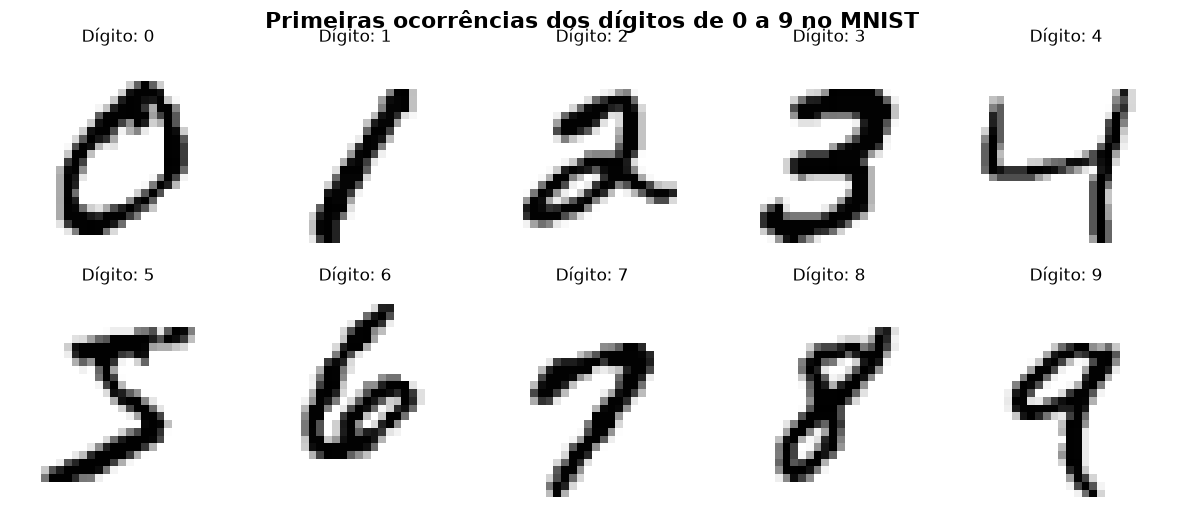

In [5]:
# Plota exemplos de imagens de cada dígito
plot_digit_samples(X, y)

### Discussão

Como vimos pela distribuição de classes, o dataset MNIST é bem equilibrado, com totais que variam entre 6.313 e 7.877 imagens por dígito.

Cada imagem é originalmente uma matriz de 28x28 pixels em escala de cinza, representando o dígito manuscrito. Cada pixel possui um valor entre 0 (preto/fundo) e 255 (branco/traço), indicando a intensidade do tom de cinza em cada ponto da imagem. Para ser utilizada na modelagem, essa matriz foi convertida em um vetor de 784 elementos (28x28), com as linhas de pixels dispostas sequencialmente. Assim, cada linha do dataset representa uma imagem de dígito manuscrito.

Embora escrevamos mais comumente com tinta escura sobre papel branco, o dataset MNIST passou por uma padronização em que os dígitos são representados com traços claros sobre fundo escuro. Isso significa que os pixels que representam o traço do dígito possuem valores mais altos (próximos de 255), enquanto os pixels do fundo possuem valores mais baixos (próximos de 0).

## Fase 2: Pré-processamento e Divisão dos Dados

In [6]:
# Divide o dataset em conjuntos de treino, validação e teste usando a função `split_data` definida em `src/preprocessing.py`. A proporção padrão, definida em `src/config.py`, é 70% para treino, 10% para validação e 20% para teste

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)


INFO - Split realizado com sucesso:
INFO -  - Treino: 48999 amostras (70.0%)
INFO -  - Validação: 7001 amostras (10.0%)
INFO -  - Teste: 14000 amostras (20.0%)


In [7]:
# Validação: confirma se a proporção das classes se manteve idêntica
split_check = pd.DataFrame({
    'Treino (%)': pd.Series(y_train).value_counts(normalize=True) * 100,
    'Validação (%)': pd.Series(y_val).value_counts(normalize=True) * 100,
    'Teste (%)': pd.Series(y_test).value_counts(normalize=True) * 100
}).sort_index()

display(split_check.round(2))

,Treino (%),Validação (%),Teste (%)
0,9.86,9.86,9.86
1,11.25,11.26,11.25
2,9.99,9.98,9.99
3,10.20,10.20,10.20
4,9.75,9.76,9.75
5,9.02,9.01,9.02
6,9.82,9.83,9.82
7,10.42,10.41,10.42
8,9.75,9.76,9.75
9,9.94,9.94,9.94


In [8]:
# Aplica a normalização dos pixels (através da divisão por 255) usando a função `scale_pixels` definida em `src/preprocessing.py`
X_train_scaled, X_val_scaled, X_test_scaled = scale_pixels(X_train, X_val, X_test)

INFO - Normalização realizada com sucesso: pixels ajustados para a escala [0.0, 1.0].


In [9]:
# Validação dos limites numéricos e tipos de dados
print(f"Treino - Mínimo: {X_train_scaled.min():.2f}, Máximo: {X_train_scaled.max():.2f}, Dtype: {X_train_scaled.dtype}")
print(f"Validação - Mínimo: {X_val_scaled.min():.2f}, Máximo: {X_val_scaled.max():.2f}, Dtype: {X_val_scaled.dtype}")
print(f"Teste - Mínimo: {X_test_scaled.min():.2f}, Máximo: {X_test_scaled.max():.2f}, Dtype: {X_test_scaled.dtype}")

Treino - Mínimo: 0.00, Máximo: 1.00, Dtype: float32
Validação - Mínimo: 0.00, Máximo: 1.00, Dtype: float32
Teste - Mínimo: 0.00, Máximo: 1.00, Dtype: float32


### Discussão

Nesta fase, foi feita a divisão do dataset em conjuntos de treino, validação e teste, utilizando a função `split_data` definida em `src/preprocessing.py`. A divisão foi realizada de forma estratificada, garantindo que a proporção de cada dígito fosse mantida em todos os conjuntos.

A normalização dos pixels foi realizada dividindo cada valor por $255.0$, convertendo os dados para o tipo `float32` no intervalo $[0.0, 1.0]$. Esta etapa é crucial para o desempenho de algoritmos de aprendizado de máquina:

- Para modelos baseados em distâncias métricas (como o KNN), a escala padronizada assegura que o cálculo da distância atribua peso equivalente a todos os pixels, evitando que atributos com maior variância numérica distorçam a similaridade entre as imagens. Em termos práticos, embora o traço do numeral seja a informação principal, a ausência de traço (o fundo) também é fundamental para diferenciar dígitos visualmente parecidos, como o 3 e o 8.

- Para modelos lineares e algoritmos de otimização (como Regressão Logística e Gradiente Descendente), a padronização deixa a superfície de erro equilibrada. Podemos imaginar que o algoritmo está descendo uma montanha no escuro em busca do ponto mais baixo (o menor erro): se as variáveis estiverem em escalas muito diferentes, o terreno fica cheio de desfiladeiros estreitos e o modelo fica dando passos em ziguezague, demorando muito para chegar ao fundo. Com a escala padronizada entre 0 e 1, o terreno vira o fundo de uma cumbuca lisa, permitindo que o algoritmo dê passos diretos e estáveis rumo ao aprendizado mais rápido.

## Fase 3: Implementação e Treinamento dos 3 Modelos

Nesta fase, serão realizados três treinamentos: dois com modelos clássicos de classificação — o K-Nearest Neighbors (KNN), baseado em distâncias métricas, e o XGBoost, baseado em árvores sequenciais de decisão — e um utilizando uma Rede Neural.

### KNN (K-Nearest Neighbors)

In [10]:
# Treinamento com KNN

# 1. Instancia o modelo base, utilizando a função `build_knn` definida em `src/models.py`. O modelo é instanciado com os hiperparâmetros padrão (n_neighbors=5, weights='distance').
knn_base = build_knn()

# 2. Define uma grade com os 2 hiperparâmetros que serão otimizados: `n_neighbors` e `weights`.
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

# 3. Configura o GridSearch com 3-fold cross-validation
grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Executa a otimização no conjunto de treino normalizado
logging.info("Iniciando a busca de hiperparâmetros com GridSearchCV para treinamento do modelo KNN...")
start_time = time.time()
grid_search_knn.fit(X_train_scaled, y_train)
fit_time_knn = time.time() - start_time
logging.info(f"Busca concluída em {fit_time_knn:.2f} segundos.")

# 5. Exibe os melhores resultados encontrados
logging.info(f"Melhores Hiperparâmetros: {grid_search_knn.best_params_}")
logging.info(f"Melhor Acurácia (Treino CV): {grid_search_knn.best_score_ * 100:.2f}%")

# 6. Avalia o melhor modelo no conjunto de Validação
best_knn = grid_search_knn.best_estimator_
y_val_pred_knn = best_knn.predict(X_val_scaled)

INFO - Criando KNN com n_neighbors=5 e weights='distance'
INFO - Iniciando a busca de hiperparâmetros com GridSearchCV para treinamento do modelo KNN...


Fitting 3 folds for each of 8 candidates, totalling 24 fits


INFO - Busca concluída em 123.04 segundos.
INFO - Melhores Hiperparâmetros: {'n_neighbors': 3, 'weights': 'distance'}
INFO - Melhor Acurácia (Treino CV): 96.84%


### XGBoost (Extreme Gradient Boosting)

In [ ]:
# Treinamento com XGBoost

# 1. Instancia o modelo base usando a função `build_xgboost` definida em `src/models.py`. O modelo é instanciado com os hiperparâmetros padrão (n_estimators=100, max_depth=3).
xgb_base = build_xgboost()

# 2. Espaço de hiperparâmetros para busca (9 combinações totais no espaço)
param_distributions_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 6, 8]
}

# 3. Configura uma busca aleatória (RandomizedSearchCV) para otimização dos hiperparâmetros do modelo XGBoost. 
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions_xgb,
    n_iter=4,
    cv=3,
    scoring='accuracy',
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2
)

# 4. Executa a otimização no conjunto de treino
logging.info("Iniciando o treinamento do XGBoost com RandomizedSearchCV...")
start_time = time.time()
random_search_xgb.fit(X_train_scaled, y_train)
fit_time_xgb = time.time() - start_time
logging.info(f"Treinamento do XGBoost concluído em {fit_time_xgb:.2f} segundos!")

# 5. Avaliação do melhor modelo encontrado
best_xgb = random_search_xgb.best_estimator_
y_val_pred_xgb = best_xgb.predict(X_val_scaled)

INFO - Instanciando XGBClassifier com n_estimators=100, max_depth=6, learning_rate=0.1, eval_metric=mlogloss
INFO - Iniciando o treinamento do XGBoost com RandomizedSearchCV...


Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ......................max_depth=8, n_estimators=100; total time= 1.2min
[CV] END ......................max_depth=8, n_estimators=100; total time= 1.2min
[CV] END ......................max_depth=8, n_estimators=100; total time= 1.2min
[CV] END ......................max_depth=3, n_estimators=100; total time=  22.2s
[CV] END ......................max_depth=3, n_estimators=100; total time=  22.1s
[CV] END ......................max_depth=3, n_estimators=100; total time=  22.4s
[CV] END ......................max_depth=6, n_estimators=150; total time= 1.2min
[CV] END ......................max_depth=6, n_estimators=150; total time= 1.1min
[CV] END ......................max_depth=6, n_estimators=150; total time= 1.2min
[CV] END .......................max_depth=3, n_estimators=50; total time=  14.0s
[CV] END .......................max_depth=3, n_estimators=50; total time=  12.2s
[CV] END .......................max_depth=3, n_es

INFO - Treinamento do XGBoost concluído em 623.76 segundos!


#### Discussão (treinamento com modelos clássicos)

No treinamento do KNN foi utilizado o `GridSearchCV` para otimizar os hiperparâmetros `n_neighbors` e `weights`.

Já no caso do XGBoost, foi utilizado o `RandomizedSearchCV` para otimizar os hiperparâmetros `n_estimators` e `max_depth`. O `GridSearchCV` aumentou demais o tempo levando na otimização dos hiperparâmetros do XGBoost, de modo a tornar seu uso impeditivo no contexto do presente projeto. A busca aleatória, então, foi utilizada para reduzir o tempo de treinamento, uma vez que limitamos os testes a apenas 4 combinações de hiperparâmetros (através do parâmetro n_iter) em vez de todas as 9 possíveis (o que ainda assim levou mais de 10 minutos no Macbook deste desenvolvedor que lhes escreve).

### Rede Neural

In [22]:
# Caminho onde o modelo fica/ficará salvo
mlp_model_path = MODELS_OUTPUT_DIR / "best_mlp_model.keras"
fit_time_mlp = np.nan
best_hps = None

if mlp_model_path.exists():
    logging.info(f"Modelo encontrado em {mlp_model_path}. Carregando modelo pré-treinado...")
    best_mlp = keras.models.load_model(mlp_model_path, compile=False)
    
    # Avaliação do modelo carregado nos dados de validação
    y_val_pred_probs = best_mlp.predict(X_val_scaled)
    y_val_pred_mlp = y_val_pred_probs.argmax(axis=1)

    print("\n--- Resultados da Rede Neural (Modelo Carregado) ---")
    print("Tempo de treinamento: indisponível (modelo carregado do disco)")
    print(f"Acurácia na Validação: {accuracy_score(y_val, y_val_pred_mlp) * 100:.2f}%")
    print("\nRelatório de Classificação:")
    print(classification_report(y_val, y_val_pred_mlp))

else:
    logging.info("Nenhum modelo salvo encontrado. Configurando e iniciando o Keras Tuner...")

    # Configuração do Tuner usando a fábrica adaptada definida em `src/models.py`. O Tuner é configurado para realizar uma busca aleatória (RandomSearch) com 6 tentativas (trials) e 1 execução por tentativa, visando maximizar a acurácia de validação.
    tuner = kt.RandomSearch(
        hypermodel=build_hyper_mlp,
        objective="val_accuracy",
        max_trials=6,
        executions_per_trial=1,
        seed=RANDOM_STATE,
        directory="keras_tuning_logs",
        project_name="mnist_mlp",
        overwrite=True
    )

    logging.info("Iniciando a otimização de hiperparâmetros da Rede Neural (MLP)...")
    start_time = time.time()

    tuner.search(
        X_train_scaled, 
        y_train, 
        epochs=10, 
        validation_data=(X_val_scaled, y_val),
        batch_size=128,
        verbose=1
    )

    fit_time_mlp = time.time() - start_time
    logging.info(f"Otimização concluída em {fit_time_mlp:.2f} segundos.")

    # Extração e avaliação do melhor modelo
    logging.info("Extraindo e avaliando o melhor modelo...")
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_mlp = tuner.get_best_models(num_models=1)[0]

    y_val_pred_probs = best_mlp.predict(X_val_scaled)
    y_val_pred_mlp = y_val_pred_probs.argmax(axis=1)

    print("\n--- Resultados da Rede Neural (Validação) ---")
    print(f"Melhor número de neurônios: {best_hps.get('units')}")
    print(f"Melhor função de ativação: {best_hps.get('activation')}")
    print(f"Melhor taxa de aprendizado: {best_hps.get('learning_rate')}")
    print(f"Acurácia na Validação: {accuracy_score(y_val, y_val_pred_mlp) * 100:.2f}%")
    print("\nRelatório de Classificação:")
    print(classification_report(y_val, y_val_pred_mlp))

    MODELS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    best_mlp.save(mlp_model_path)
    logging.info(f"Melhor modelo salvo com sucesso em: {mlp_model_path}")

INFO - Modelo encontrado em /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/models/best_mlp_model.keras. Carregando modelo pré-treinado...


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step

--- Resultados da Rede Neural (Modelo Carregado) ---
Tempo de treinamento: indisponível (modelo carregado do disco)
Acurácia na Validação: 97.61%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       690
           1       0.99      0.98      0.98       788
           2       0.97      0.99      0.98       699
           3       0.96      0.96      0.96       714
           4       0.99      0.97      0.98       683
           5       0.98      0.98      0.98       631
           6       0.97      0.99      0.98       688
           7       0.97      0.97      0.97       729
           8       0.98      0.97      0.97       683
           9       0.97      0.96      0.96       696

    accuracy                           0.98      7001
   macro avg       0.98      0.98      0.98      7001
weighted avg       0.98      0.98      0.98      7001



#### Discussão (treinamento com Rede Neural)

Já para otimizar os hiperparâmetros da Rede Neural, foi utilizado o `Keras Tuner`, através da função `build_hyper_mlp` definida em `src/models.py`. O `Keras Tuner` é uma biblioteca de otimização de hiperparâmetros para modelos Keras, que permite explorar diferentes combinações de hiperparâmetros de forma eficiente.

Os resultados dessa calibragem são, portanto:
- Melhor número de neurônios: 128
- Melhor função de ativação: relu
- Melhor taxa de aprendizado: 0.001
- Acurácia na Validação: 97.61%

## Fase 4: Avaliação Comparativa de Desempenho

TABELA COMPARATIVA CONSOLIDADA (CONJUNTO DE TESTE INDEPENDENTE)


,Modelo,Acurácia Global,Precisão (Weighted),Recall (Weighted),F1-Score (Weighted),Tempo Treino (s),Tempo Inferência (s)
0,KNN,0.9721,0.9724,0.9721,0.9721,123.0398,6.0380
1,XGBoost,0.9714,0.9715,0.9714,0.9714,623.7613,0.0892
2,MLP (Keras),0.9757,0.9758,0.9757,0.9757,NaN,0.2409


INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/confusion_matrix_knn.png



--- Classification Report Detalhado: KNN ---
              precision    recall  f1-score   support

           0     0.9752    0.9957    0.9853      1381
           1     0.9589    0.9937    0.9760      1575
           2     0.9897    0.9592    0.9742      1398
           3     0.9727    0.9713    0.9720      1428
           4     0.9842    0.9553    0.9695      1365
           5     0.9651    0.9628    0.9639      1263
           6     0.9756    0.9884    0.9819      1375
           7     0.9649    0.9794    0.9721      1459
           8     0.9870    0.9458    0.9660      1365
           9     0.9525    0.9655    0.9589      1391

    accuracy                         0.9721     14000
   macro avg     0.9726    0.9717    0.9720     14000
weighted avg     0.9724    0.9721    0.9721     14000


--- Classification Report Detalhado: XGBoost ---
              precision    recall  f1-score   support

           0     0.9778    0.9891    0.9834      1381
           1     0.9872    0.9829   

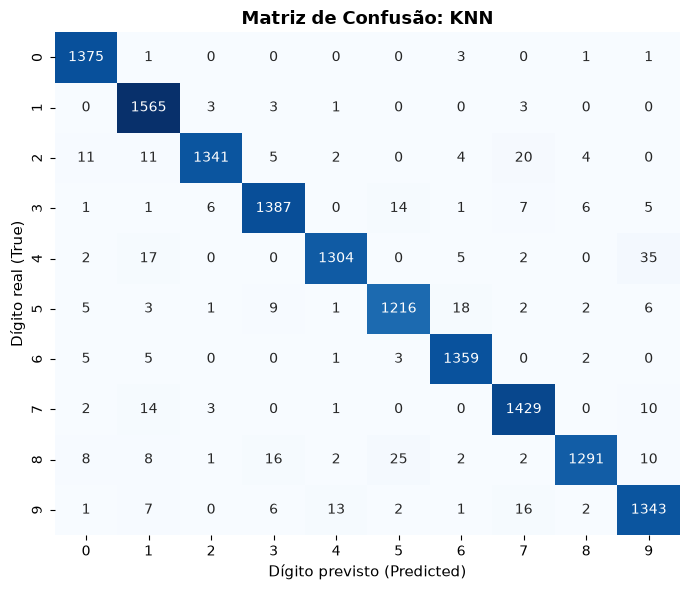

INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/confusion_matrix_xgboost.png


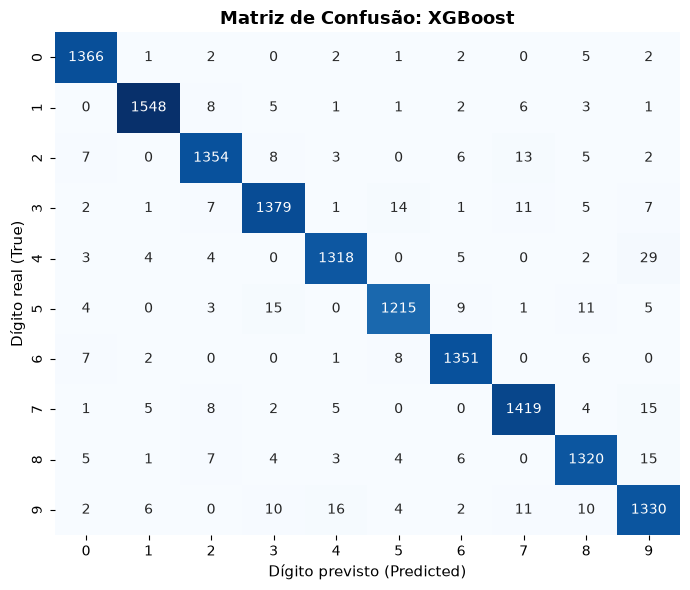

INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/confusion_matrix_mlp_keras.png


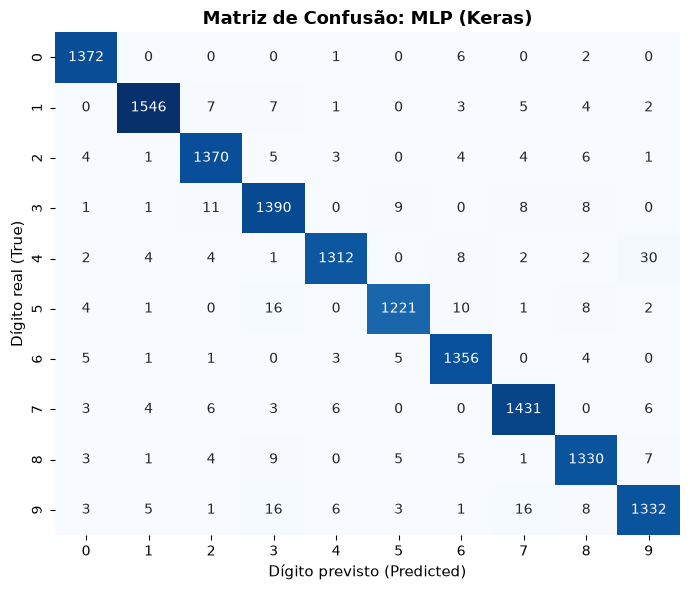


Maiores Taxas de Confusão por Modelo (Verdadeiro vs Previsto)
* KNN: Dígito 4 previsto como 9 (35x), Dígito 8 previsto como 5 (25x), Dígito 2 previsto como 7 (20x), Dígito 5 previsto como 6 (18x), Dígito 4 previsto como 1 (17x), Dígito 8 previsto como 3 (16x), Dígito 9 previsto como 7 (16x), Dígito 3 previsto como 5 (14x), Dígito 7 previsto como 1 (14x), Dígito 9 previsto como 4 (13x)
* XGBoost: Dígito 4 previsto como 9 (29x), Dígito 9 previsto como 4 (16x), Dígito 5 previsto como 3 (15x), Dígito 7 previsto como 9 (15x), Dígito 8 previsto como 9 (15x), Dígito 3 previsto como 5 (14x), Dígito 2 previsto como 7 (13x), Dígito 3 previsto como 7 (11x), Dígito 5 previsto como 8 (11x), Dígito 9 previsto como 7 (11x)
* MLP (Keras): Dígito 4 previsto como 9 (30x), Dígito 5 previsto como 3 (16x), Dígito 9 previsto como 3 (16x), Dígito 9 previsto como 7 (16x), Dígito 3 previsto como 2 (11x), Dígito 5 previsto como 6 (10x), Dígito 3 previsto como 5 (9x), Dígito 8 previsto como 3 (9x), Dígito 3 pre

In [23]:
# Modelos treinados:
models = {
    'KNN': best_knn,
    'XGBoost': best_xgb,
    'MLP (Keras)': best_mlp
}

# Tempo de treinamento de cada modelo (em segundos)
train_times = {
    'KNN': fit_time_knn,
    'XGBoost': fit_time_xgb,
    'MLP (Keras)': fit_time_mlp
}

# Executa a avaliação dos modelos treinados no conjunto de teste, utilizando a função `evaluate_models` definida em `src/evaluation.py`
df_metrics, predictions = evaluate_models(
    models=models,
    X_test=X_test_scaled,
    y_test=y_test,
    train_times=train_times
)

# Exibe a tabela consolidada de métricas de avaliação para cada modelo
print("=" * 80)
print("TABELA COMPARATIVA CONSOLIDADA (CONJUNTO DE TESTE INDEPENDENTE)")
print("=" * 80)
display(df_metrics.round(4))

# Exibe relatórios de classificação detalhados para cada modelo, utilizando a função `print_classification_reports` definida em `src/evaluation.py`
print_classification_reports(predictions, y_test)

# Renderiza e salva as Matrizes de Confusão 10x10 empilhadas individualmente
print("\n" + "=" * 80)
print("Matrizes de confusão 10x10 (heatmaps)")
print("=" * 80)

for model_name, y_pred in predictions.items():
    plot_confusion_matrix(
        y_true=y_test,
        y_pred=y_pred,
        model_name=model_name,
        figsize=(7, 6)
    )

# Diagnóstico de Maior Confusão de Dígitos por Modelo
print("\n" + format_top_confusions_summary(predictions, y_test, top_n=10))

### Discussão

Segundo a avaliação comparativa de desempenho, nas métricas de acurácia, precisão ponderada, recall e F1-score, todos os modelos apresentaram resultados muito próximos, com a Rede Neural ligeiramente à frente. No entanto, os modelos se diferenciaram muito nos tempos de treinamento.

O XGBoost teve o maior tempo de treinamento, 5 vezes o tempo do KNN e mais de 10 vezes o tempo da rede neural. Por outro lado, ele teve o menor tempo de predição (0.08s). Talvez o XGBoost seja um algoritmo bom para projetos em que haja bastante tempo para treinamento, mas em que a predição precisa ser feita em tempo real.

O algoritmo KNN teve o segundo maior tempo de treinamento (que foi mais que o dobro do tempo da Rede Neural) mas o maior tempo de predição.

Já a Rede Neural teve o menor tempo de treinamento e ainda assim um tempo muito baixo de predição, sendo o modelo que apresentou as melhores relações entre métricas de desempenho, tempos de treinamento e tempo de predição.

Obs.: O tempo de treinamento da rede neural aqui mencionado corresponde à execução do treinamento caso não haja modelo mlp já salvo. Uma vez que o modelo foi treinado, salvo na pasta outputs e resgatado para realização de inferências, o notebook não vai mais registrar o tempo de treinamento na tabela comparativa (exibindo nesta célula a informação NaN). Caso queira treinar novamente a rede neural, basta apagar o arquivo `outputs/models/best_mlp_model.keras` e executar novamente a célula de treinamento da rede neural. 

#### Erro mais comuns

Os três modelos unanimemente confundiram mais o dígito 4 previsto como se fosse o dígito 9. Curiosamente apenas o XGBoost seguiu de imediato como segundo erro mais comum a tendência reversa de alta confusão do 9 com o 4. Na KNN ela foi apenas a décima mais frequente, enquanto na rede neural essa confusão nem aparece entre as 10 mais comuns, revelando uma assimetria na forma como os modelos interpretam os traços do 4 e do 9.

O modelo KNN teve maiores concentrações de erro — 35x, 25x e 20x nos 3 mais comuns — números que foram menores nos outros modelos, indicando no geral erros menos tendenciosos no XGBoost e na rede neural.

O XGBoost apresentou uma certa tendência de dígito padrão: o 9 aparece com frequência como a predição para o 4, o 8 e o 7. O 7 também apareceu como predição para o 2, 3 e 9. 

Enquanto no XGBoost o ponto fraco foi a confusão entre o 4 e o 9 nas duas direções, na rede neural o ponto fraco foi o dígito 3, que foi algumas vezes erroneamente usado como predição para o 5, o 9 e o 8 (essa informação será interessante quando formos fazer uma inferência com um dígito manuscrito próprio). O próprio 3, ao ser encontrado, também foi confundido em várias direções (previsto como 2, 5, 7 e 8).

Considerando que a incidência de erros mais comuns foram próximas 3 nos modelos, seguimos com a rede neural como o modelo que apresentou o melhor desempenho geral, em função de sua maior acurácia, menor tempo de treinamento e tempo baixo de predição.

## Fase 5.1 Treinamento Restrito com Classes Ocultadas (Class Masking)

A partir da avaliação realizada na Fase 4, foi selecionada a rede neural para a realização dos experimentos da Fase 5, utilizando os melhores hyperparâmetros encontrados com ajuda do Keras Tuner e implementados na função `create_best_mlp`, a saber:

- `hidden_units=128`
- `activation="relu"`
- `learning_rate=0.001`

O primeiro desses experimentos é um treinamento restrito com classes ocultadas (class masking). O objetivo é verificar como a rede neural lida com dígitos manuscritos mesmo quando algumas classes são ocultadas durante o treinamento. Aqui, ocultaremos as classes 4 e 9, por terem sido as mais confundidas na Fase 4.

INFO - Classes [4, 9] removidas. Amostras restantes: 39352 de 48999
INFO - Instanciando MLP Classifier [units=128, activation=relu, lr=0.001]
/Users/felipequerette/PythonProjects/mnist-digit-recognition/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
INFO - Treinamento restrito concluído em 16.59s
INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/confusion_matrix_rede_neural_restrita_mlp_sem_as_classes_4_e_9.png


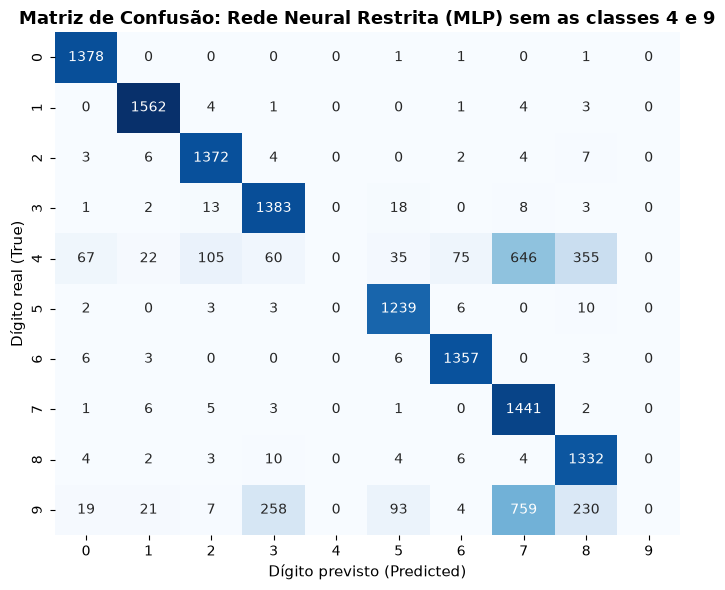

In [14]:
# 1. Definição das classes ocultadas
MASKED_CLASSES = [4, 9]

# 2. Treinamento da nova MLP restrita
masked_mlp, fit_time_masked = train_masked_mlp(
    build_model_fn=create_best_mlp,
    X_train=X_train_scaled,
    y_train=y_train,
    masked_classes=MASKED_CLASSES,
    epochs=20
)

# 3. Gerar predições no conjunto de TESTE COMPLETO
start_infer = time.perf_counter()

y_probs_masked = masked_mlp.predict(X_test_scaled, verbose=0)
y_pred_masked = np.argmax(y_probs_masked, axis=1)

infer_time_masked = time.perf_counter() - start_infer

# 4. Renderizar e salvar a Matriz de Confusão 10x10 da MLP Restrita
plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_masked,
    model_name="Rede Neural Restrita (MLP) sem as classes 4 e 9",
    figsize=(7, 6)
)

#### Discussão

Conforme o log, nosso conjunto de treino original tinha 48.999 imagens (70% do nosso dataset de 70.000 imagens, conforme split realizado na Fase 2). Após a filtragem das classes 4 e 9, restaram 39.352 imagens.

Como é possível ver na matriz de confusão, como o treino não continha as classes 4 e 9, nenhuma previsão foi feita para esses dois dígitos que ficaram com suas respectivas colunas completamente zeradas.

Ao receber as imagens 4 e 9 do conjunto de teste completo, o modelo tentou encaixá-las nas categorias que ele conhecia:
- Os 9 foram predominantemente entendidos como 7, mas também alguns 3 e 8.
- Já os 4 foram predominantemente confundidos com 7 e 8.

## Fase 5.2 Teste de Generalização Extrema

INFO - Dataset OOD isolado para as classes [4, 9]. Amostras mantidas: 2756 de 14000
INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/confusion_matrix_avaliação_ood_-_exclusivo_classes_ocultadas_4_e_9.png


Total de amostras OOD testadas: 2756
Confiança Média atribuída às predições: 86.46%
Confiança Mediana atribuída às predições: 95.31%


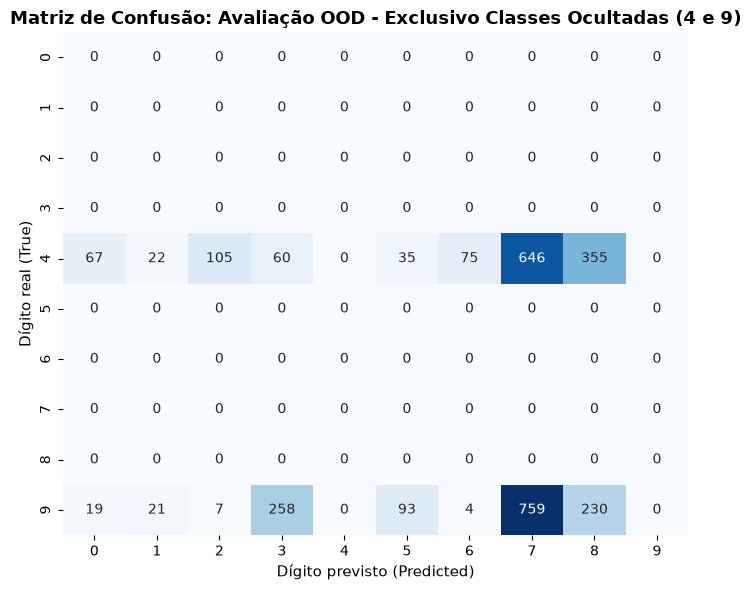

In [15]:
# 1. Isolar apenas as amostras de teste dos dígitos 4 e 9 (OOD Extremo)
X_test_ood, y_test_ood = filter_ood_dataset(
    X_test_scaled, y_test, target_classes=MASKED_CLASSES
)

# 2. Executar a inferência OOD e extrair métricas de confiança
ood_results = analyze_ood_confidence(masked_mlp, X_test_ood)

print(f"Total de amostras OOD testadas: {len(y_test_ood)}")
print(f"Confiança Média atribuída às predições: {ood_results['mean_confidence']:.2%}")
print(f"Confiança Mediana atribuída às predições: {ood_results['median_confidence']:.2%}")

# 3. Gerar a Matriz de Confusão OOD
plot_confusion_matrix(
    y_true=y_test_ood,
    y_pred=ood_results["y_pred"],
    model_name="Avaliação OOD - Exclusivo Classes Ocultadas (4 e 9)",
    figsize=(7, 6)
)

Como na etapa anterior fizemos um teste preliminar com o já previamente definido conjunto de testes e agora criamos um dataset exclusivo com apenas as classes 4 e 9 *a partir do conjunto de teste*, os resultados da matriz de confusão foram os mesmos.

A título de ampliar o teste, vamos em seguida realizar o mesmo teste OOD num dataset da base completa. Afinal, o modelo aqui foi treinado SEM as classes 4 e 9, de modo que um dataset exclusivo com as classes 4 e 9 não corre o risco de data leakage.

INFO - Dataset OOD isolado para as classes [4, 9]. Amostras mantidas: 13782 de 70000
INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/confusion_matrix_avaliação_ood_em_larga_escala_-_classes_ocultadas_4_e_9.png


Total de amostras OOD Testadas: 13782)
Confiança Média do Modelo nos Erros: 86.18%
Confiança Mediana do Modelo nos Erros: 94.94%


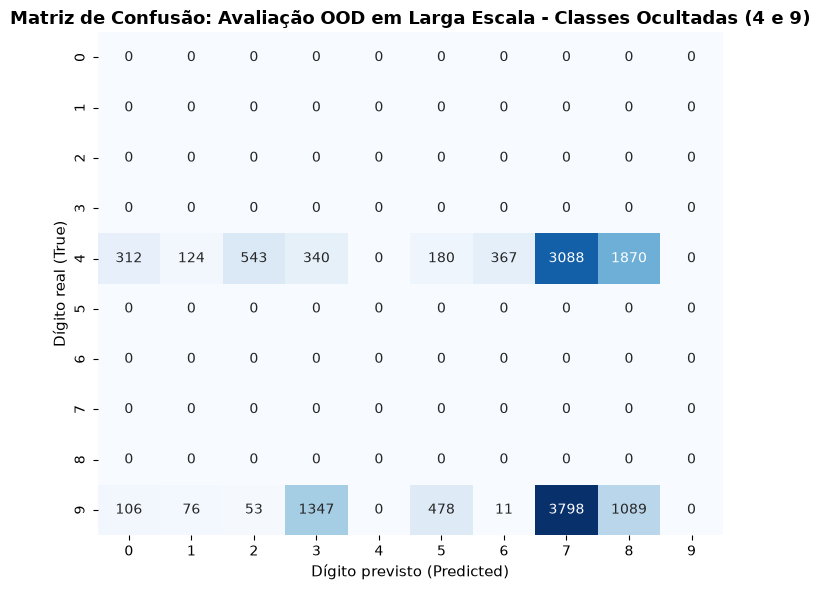

In [ ]:
# 1. Unir todas as amostras disponíveis do dataset
X_full = np.vstack([X_train_scaled, X_val_scaled, X_test_scaled])
y_full = np.concatenate([y_train, y_val, y_test])

# 2. Isolar apenas as amostras de 4 e 9 de TODA a base
X_ood_full, y_ood_full = filter_ood_dataset(
    X_full, y_full, target_classes=MASKED_CLASSES
)

# 3. Executar a inferência e análise de confiança no volume total
ood_full_results = analyze_ood_confidence(masked_mlp, X_ood_full)

print(f"Total de amostras OOD Testadas: {len(y_ood_full)})")
print(f"Confiança Média do Modelo nos Erros: {ood_full_results['mean_confidence']:.2%}")
print(f"Confiança Mediana do Modelo nos Erros: {ood_full_results['median_confidence']:.2%}")

# 4. Matriz de Confusão OOD em Larga Escala
plot_confusion_matrix(
    y_true=y_ood_full,
    y_pred=ood_full_results["y_pred"],
    model_name="Avaliação OOD em Larga Escala - Classes Ocultadas (4 e 9)",
    figsize=(7, 6)
)

#### Discussão

Os resultados do teste OOD na base completa mostraram que o modelo teve confianças médias e medianas altas, mesmo tendo sido confrontado com classes que não foram vistas durante o treinamento.

Ao reconhecer características similares entre o dígito 4 ou 9 e os dígitos que ele conhecia, o modelo fez previsões com alta confiança, ainda que incorretas. Isso indica que o modelo aprendeu a identificar padrões visuais nos dígitos. Como o modelo não tem uma classe "desconhecida" para enviar o sinal para ela, ao prever um numeral novo ele dispara uma classe conhecida com a máxima força disponível.

Novamente, o 9 foi predominantemente entendido como 7, mas também alguns 3, 8 e 5. Enquanto o 4 ficou dividido entre 7 e 8, com uma pequena quantidade de outros dígitos.

No caso do 9 parece muito nítida a capacidade de percepção visual do traço inferior (uma perninha) do 9 — confundida com outros dígitos com a mesma característica, como o 7 e o 3 — e da bolinha superior, confundida com o 8.

## Fase 5.3 Inferência com Imagens Manuscritas Próprias

INFO - Imagem custom-4.png processada com sucesso.


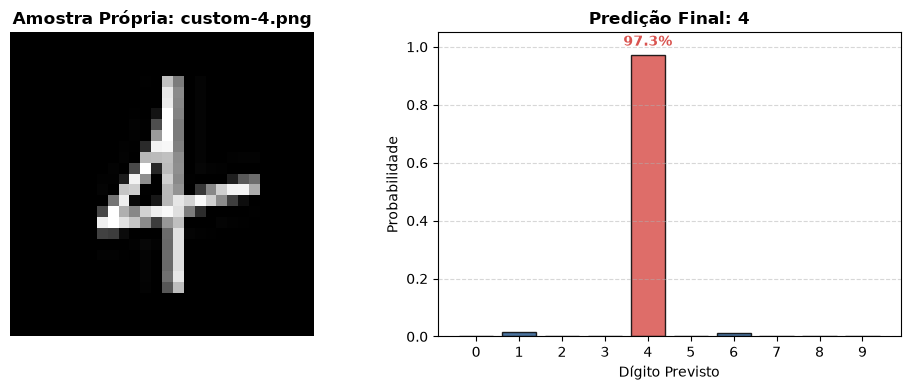

In [17]:
# Inferência com imagem manuscrita própria: 4

image_path = PROJECT_ROOT / "data" / "custom" / "custom-4.png"

img_28x28, df_pixels = process_custom_digit_to_df(image_path, invert_colors=True)

X_custom = img_28x28.reshape(1, 784)

probs_custom = best_mlp.predict(X_custom, verbose=0)[0]

plot_custom_digit_prediction(
    img_array=img_28x28,
    probabilities=probs_custom,
    image_title=f"Amostra Própria: {image_path.name}",
    save_path=IMAGES_OUTPUT_DIR / f"prediction_{image_path.stem}.png"
)

INFO - Imagem custom-9.png processada com sucesso.


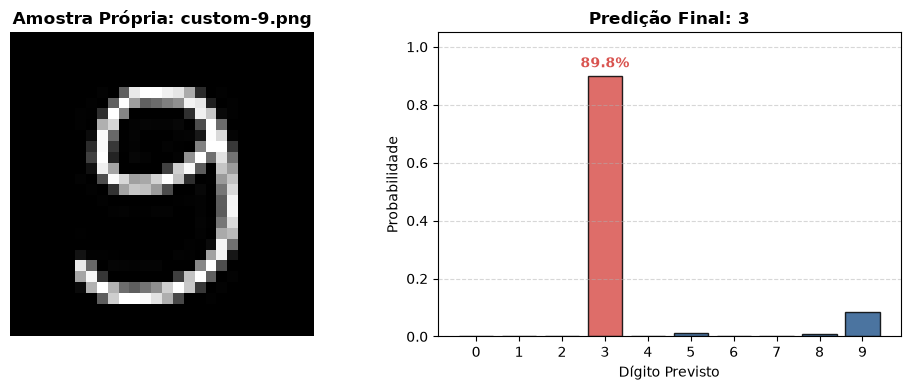

Probabilidades por Dígito para o 9:
Dígito 0: 0.01%
Dígito 1: 0.00%
Dígito 2: 0.00%
Dígito 3: 89.78%
Dígito 4: 0.00%
Dígito 5: 1.05%
Dígito 6: 0.00%
Dígito 7: 0.00%
Dígito 8: 0.80%
Dígito 9: 8.36%


In [20]:
# Inferência com imagem manuscrita própria: 9

image_path = PROJECT_ROOT / "data" / "custom" / "custom-9.png"

img_28x28, df_pixels = process_custom_digit_to_df(image_path, invert_colors=True)

X_custom = img_28x28.reshape(1, 784)

probs_custom = best_mlp.predict(X_custom, verbose=0)[0]

plot_custom_digit_prediction(
    img_array=img_28x28,
    probabilities=probs_custom,
    image_title=f"Amostra Própria: {image_path.name}",
    save_path=IMAGES_OUTPUT_DIR / f"prediction_{image_path.stem}.png"
)

print("Probabilidades por Dígito para o 9:")
for digito, prob in enumerate(probs_custom):
    print(f"Dígito {digito}: {prob * 100:.2f}%")

#### Discussão

O modelo de rede neural previu corretamente o dígito 4 escrito manualmente pelo presente desenvolvedor, mas errou na predição do dígito 9! A imagem do 4 foi prevista com 97,3% de confiança, enquanto a imagem do 9 foi confundida com um 3 com 89,8% de confiança. O modelo apresentou uma pequena probabilidade de 8.36% de que a imagem do 9 fosse realmente um 9.

Numerais manuscritos têm diferentes grafias aceitas. Um 2 pode ser por exemplo um patinho na lagoa ou ter um laço na porção inferior. O meu 4 manuscrito segue uma imagem que lembra um barco à vela, com topo fechado e traços perpendiculares, mas o 4 também pode ser escrito com topo aberto e mais arredondado. Tudo indica que essas diferenças na grafia fazem com que o modelo se confunda mais ou menos. Por isso, embora nos testes com os dados do MNIST o 4 ser confundido com um 9 foi o tipo de erro mais comum, no meu caso individual isso não se manifestou.

Já o 9 manuscrito aqui terminou sendo um exemplo do terceiro erro mais frequente visto no treinamento da rede neural, que é a confusão do 9 com o 3. (O meu 9 manuscrito tem um traço inferior que se prolonga para a esquerda. Isso parece ter sido suficiente para que o modelo confundisse o 9 com o 3.)

As inferências do modelo MLP nas amostras customizadas parecem, portanto, refletir o impacto direto do estilo de escrita na distribuição de probabilidades.

Curiosidade: durante o desenvolvimento do presente projeto, o modelo de rede neural passou por uma configuração que chegou a acertar o dígito 9 customizado, mas esse modelo foi substituído ao ser rodado novamente porque ainda não havia sido estabelecida uma semente fixa no Keras Tuner. Para evitar futuras inconsistências, além da semente fixa, o melhor modelo de rede neural foi salvo na pasta outputs/models para termos guardado o modelo que corresponde à análise e interpretação realizadas presentes neste notebook.